In [2]:
# https://www.marktechpost.com/2026/04/27/how-to-build-a-lightweight-vision-language-action-inspired-embodied-agent-with-latent-world-modeling-and-model-predictive-control/

In [3]:
import random, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Dict, List
from torch.utils.data import Dataset, DataLoader
from torch import device
try:
   from tqdm.auto import tqdm
except Exception:
   def tqdm(x, **kwargs): return x


SEED = 7
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)


if device.type == "cuda":
   torch.backends.cudnn.benchmark = True



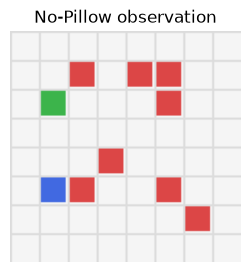

In [6]:
@dataclass
class WorldConfig:
    grid_size: int=8
    cell_px: int=14
    max_steps: int=45
    n_obstacles: int=8
    spawn_margin: int=1

class GridWorld:
    ACTION_NAMES = { 0: "UP", 1: "DOWN", 2: "LEFT", 3:"RIGHT" }
    ACTIONS = { 0: (0, -1), 1: (0, 1), 2: (-1, 0), 3: (1, 0) }

    def __init__(self, cfg: WorldConfig):
        self.cfg = cfg
        self.reset()

    def reset(self) -> Dict:
        g = self.cfg.grid_size
        self.steps = 0

        def sample_empty(exclude=set()):
            while True:
                x = random.randint(self.cfg.spawn_margin, g-1-self.cfg.spawn_margin)
                y = random.randint(self.cfg.spawn_margin, g-1-self.cfg.spawn_margin)
                if (x,y) not in exclude: 
                    return (x,y)
        self.obstacles = set()
        ax, ay = sample_empty()
        gx, gy = sample_empty(exclude=[(ax, ay)])
        used = {(ax,ay),(gx,gy)}
        for _ in range(self.cfg.n_obstacles):
            ox, oy = sample_empty(exclude=used)
            self.obstacles.add((ox,oy))
            used.add((ox,oy))
        self.agent = (ax,ay)
        self.goal = (gx,gy)
        return {"image": self._render_u8()}

    def _in_bounds(self, x, y):
       return 0 <= x < self.cfg.grid_size and 0 <= y < self.cfg.grid_size


    def _dist_to_goal(self, pos: Tuple[int,int]) -> float:
        x,y = pos; gx,gy = self.goal
        return abs(x-gx)+abs(y-gy)


    def _state_vector(self) -> np.ndarray:
        g = self.cfg.grid_size - 1
        ax, ay = self.agent
        gx, gy = self.goal
        return np.array([ax/g, ay/g, gx/g, gy/g], dtype=np.float32)

    def step(self, action: int):
        self.steps += 1
        dx, dy = self.ACTIONS[int(action)]
        x, y = self.agent
        nx, ny = x+dx, y+dy
        if self._in_bounds(nx, ny) and (nx, ny) not in self.obstacles:
            self.agent = (nx, ny)
        done = (self.agent == self.goal) or (self.steps >= self.cfg.max_steps)
        d_prev = self._dist_to_goal((x,y))
        d_now = self._dist_to_goal(self.agent)
        reward = 0.1*(d_prev - d_now) + (1.0 if self.agent == self.goal else 0.0)
        obs = {"image": self._render_u8()}
        info = {"state": self._state_vector()}
        return obs, float(reward), bool(done), info

    def _render_u8(self) -> np.ndarray:
        g, s = self.cfg.grid_size, self.cfg.cell_px
        H = W = g*s
        bg = np.array([245,245,245], np.uint8)
        gridline = np.array([220,220,220], np.uint8)
        obstacle_c = np.array([220,70,70], np.uint8)
        goal_c = np.array([60,180,75], np.uint8)
        agent_c = np.array([65,105,225], np.uint8)
        img = np.empty((H,W,3), np.uint8); img[...] = bg
        img[::s,:,:] = gridline
        img[:,::s,:] = gridline
        def paint_cell(x,y,color):
            y0,y1 = y*s,(y+1)*s
            x0,x1 = x*s,(x+1)*s
            img[y0+1:y1-1, x0+1:x1-1] = color
        for (ox,oy) in self.obstacles: paint_cell(ox,oy, obstacle_c)
        gx,gy = self.goal; paint_cell(gx,gy, goal_c)
        ax,ay = self.agent; paint_cell(ax,ay, agent_c)
        return img

cfg = WorldConfig()
env = GridWorld(cfg)
plt.figure(figsize=(3,3))
plt.imshow(env.reset()["image"]); plt.axis("off"); plt.title("No-Pillow observation"); plt.show()


def to_tensor_img_u8(img_u8: np.ndarray) -> torch.Tensor:
   return torch.from_numpy(img_u8).permute(2,0,1).float() / 255.0


In [ ]:
class TransitionDataset(Dataset):
    def __init__(self, items) -> None:
        super().__init__()
        self.items = items
    def __len__(self):
        return len(self.items)

def collect_transitions(n_episodes=120):
    items = []
    env = GridWorld(cfg=cfg)
    for _ in tqdm(range(n_episodes), desc="Collect"):
        obs = env.reset()
        
